In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from sklearn.model_selection import train_test_split

In [11]:
#Dataset Setup and Analysis

np.random.seed(42)
tf.random.set_seed(42)

class TrafficSignDataset:
    def __init__(self, data_path):
        self.data_path = Path(data_path)
        self.classes = ['20_speed_limit', '60_speed_limit', 'bike_lane', 
                       'children_crossing', 'do_not_enter', 
                       'pedestrian_crossing', 'stop']
        self.num_classes = len(self.classes)
        
    def load_dataset(self):
        """Load images and labels from Train, Test, Val folder structure"""
        splits = ['Train', 'Test', 'Val']
        images = {'train': [], 'test': [], 'val': []}
        labels = {'train': [], 'test': [], 'val': []}
        
        for split in splits:
            split_path = self.data_path / split
            if split_path.exists():
                for class_idx, class_name in enumerate(self.classes):
                    class_path = split_path / class_name
                    if class_path.exists():
                        for img_file in class_path.glob('*.*'):
                            #read image
                            img = cv2.imread(str(img_file))
                            if img is not None:
                                #resize to 32x32 as in the methodology
                                img = cv2.resize(img, (32, 32))
                                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                                
                                split_key = split.lower()
                                images[split_key].append(img)
                                labels[split_key].append(class_idx)
        
        for split in images:
            images[split] = np.array(images[split])
            labels[split] = np.array(labels[split])
            
        return images, labels

dataset = TrafficSignDataset('datanozerodce')
images, labels = dataset.load_dataset()

In [12]:
print("Dataset sizes:")
for split in ['train', 'test', 'val']:
    print(f"{split.capitalize()}: {len(images[split])} images")

print(f"Total classes: {dataset.num_classes}")
if len(images['train']) > 0:
    print(f"Image shape: {images['train'][0].shape}")

Dataset sizes:
Train: 5460 images
Test: 1456 images
Val: 1685 images
Total classes: 7
Image shape: (32, 32, 3)



Training Set Distribution:
                 Class  Count  Class_ID
0       20_speed_limit    210         0
1       60_speed_limit   1881         1
2            bike_lane    274         2
3    children_crossing    692         3
4         do_not_enter   1329         4
5  pedestrian_crossing    264         5
6                 stop    810         6

Test Set Distribution:
                 Class  Count  Class_ID
0       20_speed_limit    208         0
1       60_speed_limit    208         1
2            bike_lane    208         2
3    children_crossing    208         3
4         do_not_enter    208         4
5  pedestrian_crossing    208         5
6                 stop    208         6

Validation Set Distribution:
                 Class  Count  Class_ID
0       20_speed_limit    240         0
1       60_speed_limit    240         1
2            bike_lane    242         2
3    children_crossing    241         3
4         do_not_enter    241         4
5  pedestrian_crossing    241         

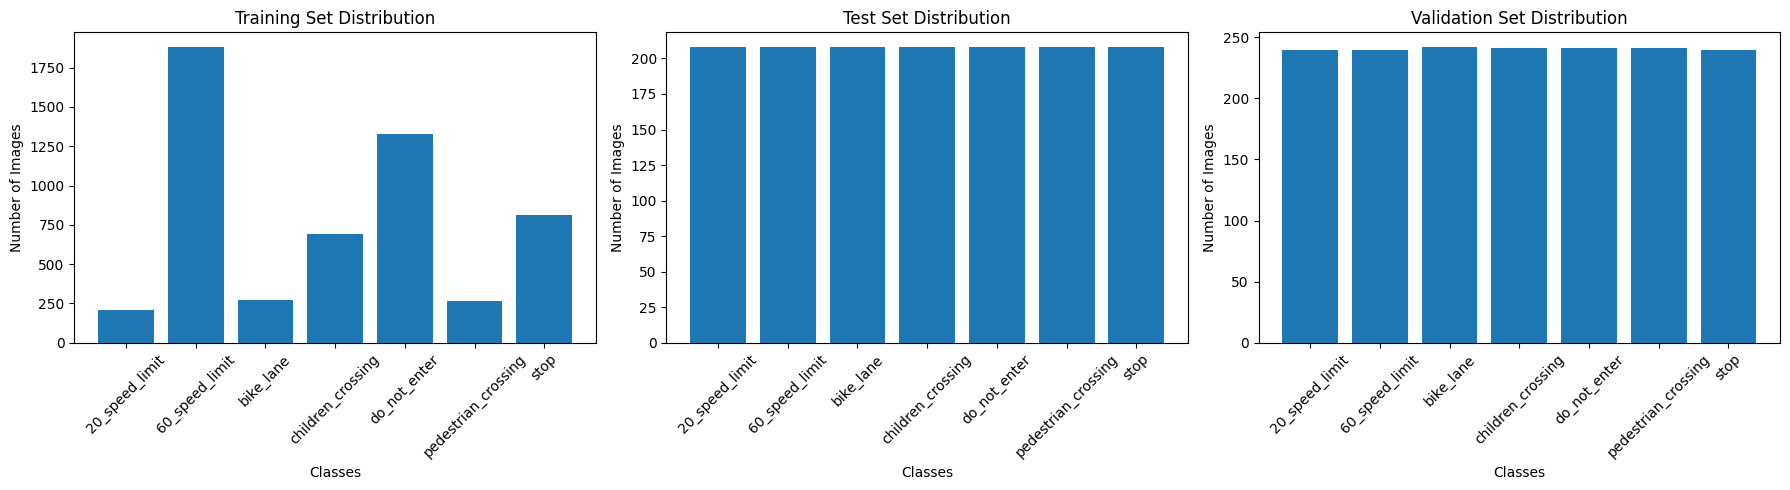

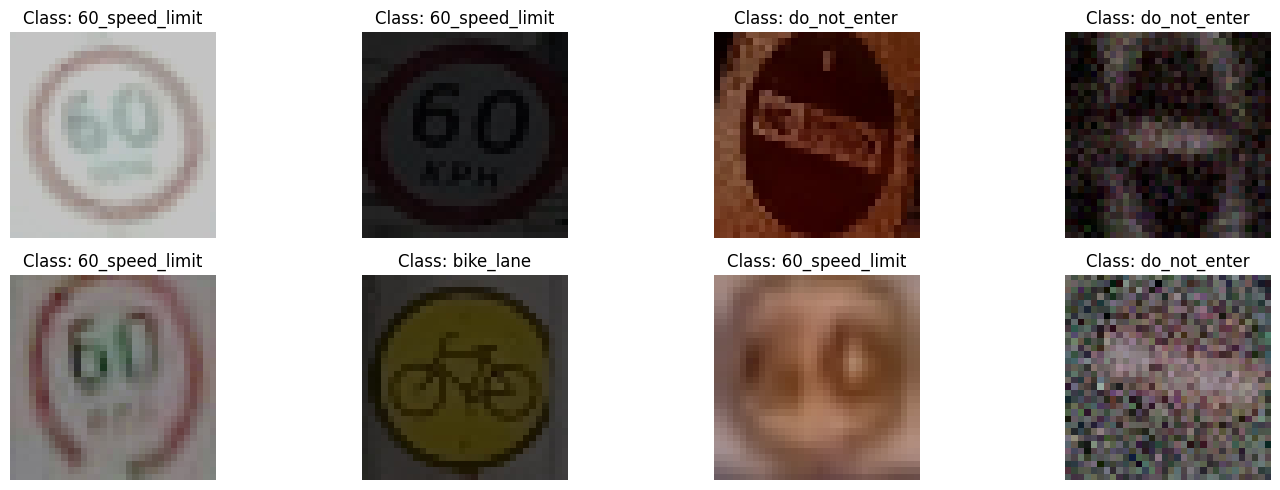

In [13]:
#Data Analysis and Visualization
def analyze_dataset(images, labels, classes):
    
    splits = ['train', 'test', 'val']
    split_titles = ['Training Set', 'Test Set', 'Validation Set']
    
    plt.figure(figsize=(18, 5))
    
    for idx, (split, title) in enumerate(zip(splits, split_titles)):
        plt.subplot(1, 3, idx+1)
        if len(labels[split]) > 0:
            unique, counts = np.unique(labels[split], return_counts=True)
            plt.bar([classes[i] for i in unique], counts)
            plt.title(f'{title} Distribution')
            plt.xlabel('Classes')
            plt.ylabel('Number of Images')
            plt.xticks(rotation=45)
            
            print(f"\n{title} Distribution:")
            df_split = pd.DataFrame({
                'Class': [classes[i] for i in unique],
                'Count': counts,
                'Class_ID': unique
            })
            print(df_split)
        else:
            plt.text(0.5, 0.5, f'No {split} data', ha='center', va='center')
            plt.title(f'{title} Distribution')
    
    plt.tight_layout()
    plt.show()
    
    #display sample images
    if len(images['train']) > 0:
        plt.figure(figsize=(15, 5))
        sample_indices = random.sample(range(len(images['train'])), min(8, len(images['train'])))
        for i, idx in enumerate(sample_indices):
            plt.subplot(2, 4, i+1)
            plt.imshow(images['train'][idx])
            plt.title(f'Class: {classes[labels["train"][idx]]}')
            plt.axis('off')
        plt.tight_layout()
        plt.show()

analyze_dataset(images, labels, dataset.classes)

In [14]:
#Data Preprocessing and Augmentation (TRAINING SET ONLY)
class DataPreprocessor:
    def __init__(self, target_size=(32, 32)):
        self.target_size = target_size
    
    def augment_image(self, image):
    #apply random augmentaion to images
        image = cv2.resize(image, self.target_size)
        
        aug_type = random.choice(['rotate', 'zoom', 'brightness', 
                                  'gaussian_noise', 'none'])
        
        if aug_type == 'rotate':
            angle = random.uniform(-15, 15)
            matrix = cv2.getRotationMatrix2D(
                (self.target_size[0]//2, self.target_size[1]//2), angle, 1.0
            )
            result = cv2.warpAffine(image, matrix, self.target_size)
            
        elif aug_type == 'zoom':
            zoom_factor = random.uniform(0.8, 1.2)
            new_size = int(self.target_size[0] * zoom_factor)
            resized = cv2.resize(image, (new_size, new_size))
            if zoom_factor > 1:
                start = (new_size - self.target_size[0]) // 2
                cropped = resized[start:start+self.target_size[0], start:start+self.target_size[1]]
                result = cv2.resize(cropped, self.target_size)  # Final resize to ensure exact size
            else:
                pad = (self.target_size[0] - new_size) // 2
                padded = cv2.copyMakeBorder(resized, pad, pad, pad, pad, cv2.BORDER_REFLECT)
                result = cv2.resize(padded, self.target_size)  # Final resize to ensure exact size
                
        elif aug_type == 'brightness':
            hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
            hsv = hsv.astype(np.float32)
            hsv[:,:,2] *= random.uniform(0.7, 1.3)
            hsv[:,:,2] = np.clip(hsv[:,:,2], 0, 255)
            hsv = hsv.astype(np.uint8)
            result = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)
            
        elif aug_type == 'gaussian_noise':
            noise = np.random.normal(0, 25, image.shape).astype(np.int16)
            noisy_image = np.clip(image.astype(np.int16) + noise, 0, 255).astype(np.uint8)
            result = noisy_image
        
        else:
            result = image
        
        return cv2.resize(result, self.target_size)

    def augment_training_data(self, images, labels, augmentation_factor=2):
        augmented_images = []
        augmented_labels = []
        
        print("Applying data augmentation to training set...")
        
        for img, label in zip(images, labels):
            #add original image
            img_resized = cv2.resize(img, self.target_size)
            augmented_images.append(img_resized)
            augmented_labels.append(label)
            
            #add augmented version of the image
            for _ in range(augmentation_factor):
                aug_img = self.augment_image(img)
                aug_img_resized = cv2.resize(aug_img, self.target_size)
                augmented_images.append(aug_img_resized)
                augmented_labels.append(label)
        
        augmented_images = np.stack(augmented_images, axis=0)
        augmented_labels = np.array(augmented_labels)
        
        print(f"Training set after augmentation: {len(augmented_images)} images")
        print(f"Final image shape: {augmented_images[0].shape}")
        return augmented_images, augmented_labels

In [19]:
#run preprocessor
preprocessor = DataPreprocessor()

#apply augmentation to training
X_train_aug, y_train_aug = preprocessor.augment_training_data(
    images['train'], labels['train'], augmentation_factor=1
)

#use original test and val dataset
X_test = images['test']
y_test = labels['test']
X_val = images['val']
y_val = labels['val']

print(f"\nFinal dataset sizes:")
print(f"Training set: {len(X_train_aug)} images")
print(f"Validation set: {len(X_val)} images")
print(f"Test set: {len(X_test)} images")

Applying data augmentation to training set...
Training set after augmentation: 10920 images
Final image shape: (32, 32, 3)

Final dataset sizes:
Training set: 10920 images
Validation set: 1685 images
Test set: 1456 images


In [21]:
#normalize
X_train_aug = X_train_aug.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

#convert labels to one-hot (categorical)
y_train_cat = keras.utils.to_categorical(y_train_aug, num_classes=dataset.num_classes)
y_val_cat = keras.utils.to_categorical(y_val, num_classes=dataset.num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=dataset.num_classes)

y_train_orig = y_train_aug
y_val_orig = y_val
y_test_orig = y_test

In [23]:
all_classes = np.arange(dataset.num_classes)
existing_classes = np.unique(y_train_aug)

computed_weights = compute_class_weight(
    class_weight='balanced',
    classes=existing_classes,
    y=y_train_aug
)

class_weight_dict = {
    int(cls): float(computed_weights[list(existing_classes).index(cls)]) if cls in existing_classes else 1.0
    for cls in all_classes
}

print("\nClass weights:")
for class_idx, weight in class_weight_dict.items():
    print(f"Class {dataset.classes[class_idx]}: {weight:.4f}")


Class weights:
Class 20_speed_limit: 3.7143
Class 60_speed_limit: 0.4147
Class bike_lane: 2.8467
Class children_crossing: 1.1272
Class do_not_enter: 0.5869
Class pedestrian_crossing: 2.9545
Class stop: 0.9630


In [25]:
#BASE MODEL (VGG INSPIRED)
def create_vgg_model(input_shape=(32, 32, 3), num_classes=7):
    
    model = keras.Sequential([
        # 1st Convolutional Block
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', 
                     input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # 2nd conv block
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # 3rd conv block
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        #4th conv block
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),
        
        # fc layers
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

#create model
model = create_vgg_model(num_classes=dataset.num_classes)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 batch_normalization (BatchN  (None, 32, 32, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 32)       0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 16, 16, 32)        0         
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 64)        1

In [10]:
#MODEL TRAINING WITH CLASS WEIGHTS

#compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Learning rate scheduler
def lr_scheduler(epoch, lr):
    if epoch > 20:
        return lr * 0.1
    elif epoch > 40:
        return lr * 0.01
    return lr

lr_callback = keras.callbacks.LearningRateScheduler(lr_scheduler)

#Early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True
)

#Train model with class weights
print("Training model with class weights...")
history = model.fit(
    X_train_aug, y_train_cat,
    batch_size=32,
    epochs=50,
    validation_data=(X_val, y_val_cat),
    callbacks=[lr_callback, early_stopping],
    class_weight=class_weight_dict,
    verbose=1
)

Training model with class weights...
Epoch 1/50
289/289 [==============================] - 71s 198ms/step - loss: 1.6275 - accuracy: 0.4111 - val_loss: 2.8692 - val_accuracy: 0.1669 - lr: 0.0010
Epoch 2/50
289/289 [==============================] - 68s 234ms/step - loss: 0.9065 - accuracy: 0.6440 - val_loss: 1.5801 - val_accuracy: 0.5433 - lr: 0.0010
Epoch 3/50
289/289 [==============================] - 56s 194ms/step - loss: 0.3778 - accuracy: 0.8576 - val_loss: 0.8869 - val_accuracy: 0.7658 - lr: 0.0010
Epoch 4/50
289/289 [==============================] - 56s 195ms/step - loss: 0.2015 - accuracy: 0.9284 - val_loss: 1.0668 - val_accuracy: 0.7761 - lr: 0.0010
Epoch 5/50
289/289 [==============================] - 56s 195ms/step - loss: 0.1560 - accuracy: 0.9481 - val_loss: 0.6469 - val_accuracy: 0.8221 - lr: 0.0010
Epoch 6/50
289/289 [==============================] - 57s 198ms/step - loss: 0.1243 - accuracy: 0.9619 - val_loss: 0.7033 - val_accuracy: 0.8262 - lr: 0.0010
Epoch 7/50
289/

Model loaded from base_model.h5
46/46 [==============================] - 1s 19ms/step
Test Accuracy: 0.9217 (92.17%)


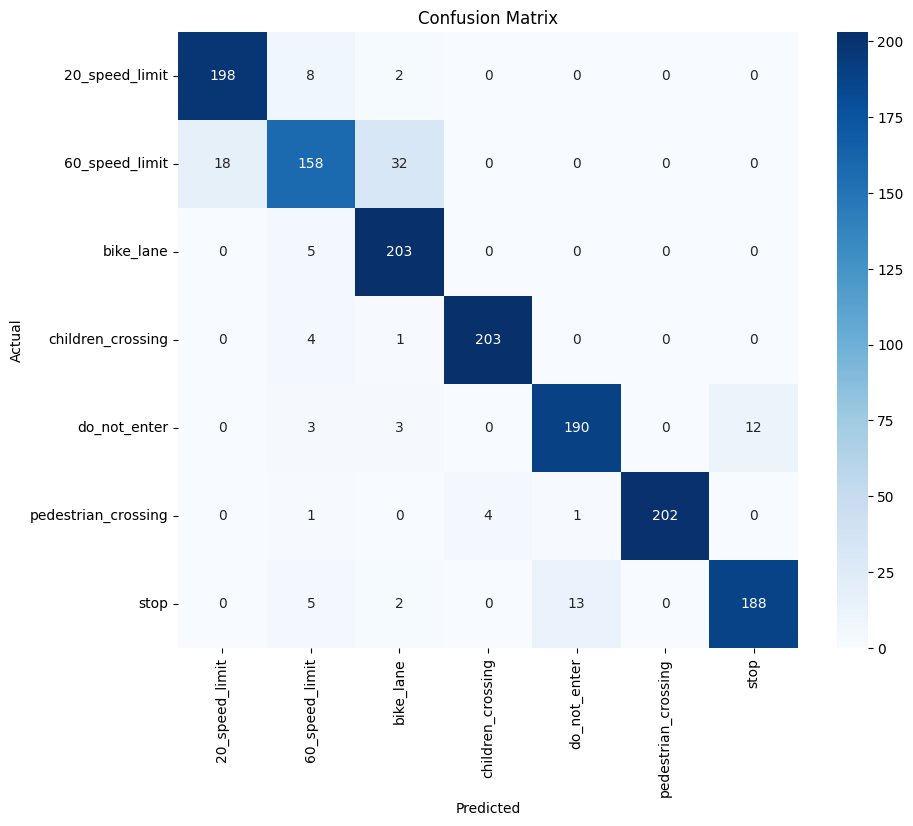


Classification Report:
                     precision    recall  f1-score   support

     20_speed_limit       0.92      0.95      0.93       208
     60_speed_limit       0.86      0.76      0.81       208
          bike_lane       0.84      0.98      0.90       208
  children_crossing       0.98      0.98      0.98       208
       do_not_enter       0.93      0.91      0.92       208
pedestrian_crossing       1.00      0.97      0.99       208
               stop       0.94      0.90      0.92       208

           accuracy                           0.92      1456
          macro avg       0.92      0.92      0.92      1456
       weighted avg       0.92      0.92      0.92      1456



In [29]:
# EVALUATION AND RESULTS
from tensorflow.keras.models import load_model

model_path = "base_model.h5" 
model = load_model(model_path)
print(f"Model loaded from {model_path}")


def evaluate_model(model, X_test, y_test, y_test_orig, classes):
    
    #predictions
    y_pred = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred, axis=1)
    
    #accuracy
    test_accuracy = np.sum(y_pred_classes == y_test_orig) / len(y_test_orig)
    print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    
    #confusion matrix
    cm = confusion_matrix(y_test_orig, y_pred_classes)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    #classification report
    print("\nClassification Report:")
    print(classification_report(y_test_orig, y_pred_classes, 
                              target_names=classes))
    
    return test_accuracy, y_pred_classes

#evaluate model
test_accuracy, predictions = evaluate_model(model, X_test, y_test_cat, 
                                          y_test_orig, dataset.classes)

In [12]:
#SAVE MODEL
model.save('base_model.h5')

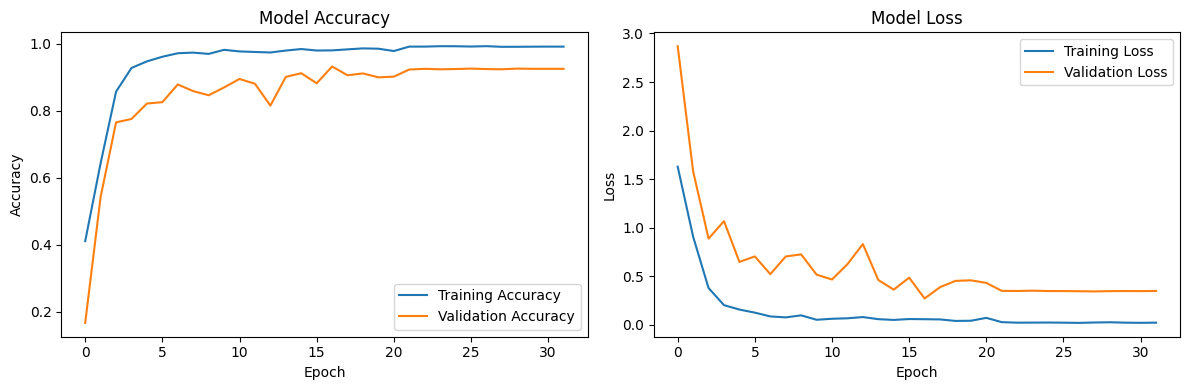

In [13]:
#training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()